In [2]:
import keras
import numpy as np
import tensorflow as tf
from scipy import signal
from matplotlib import pyplot as plt

In [3]:
num_taps = 2 # number of parameters
batch_size = 64

In [28]:
def generate_data(num_samples=1000, noise_factor=0.5):
    np.random.seed(42)
    t = np.linspace(0, 1, num_samples, dtype=np.float32)
    s = np.sin(2 * np.pi * t,dtype=np.float32)  # Clean signal
    n = noise_factor * np.random.normal(size=num_samples)  # Noise
    x = s + n  # Noisy signal
    x.astype(dtype=np.float32)
    s.astype(dtype=np.float32)
    return x, s


def create_seq(x:np.array, seq_len=10, n_samples=1000):
    # seq = np.zeros(shape=(seq_len, n_samples//seq_len))
    new_x = []
    seq = []
    for i in range(seq_len, n_samples):
        seq.append(x[i-seq_len:i])
    seq = np.array(seq)
    new_x.append(seq)
    return np.array(new_x)


def apply_fir(x:np.array, f_params:tuple, f_name:str="butter"):
    if f_name == "butter":
        N, Wn = f_params
        N = int(N)
        Wn = abs(Wn)
        b, a = signal.butter(N=N, Wn=Wn)
    else:
        raise ValueError
    y = signal.filtfilt(b, a, x)
    return y


model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(batch_size,)), # must match batch size
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(num_taps) # FIR params
])

/home/sergiusz/ML_Filter/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.input_shape

(None, 64)

In [6]:
# Instantiate an optimizer.
optimizer = keras.optimizers.SGD(learning_rate=1e-3)
# Instantiate a loss function.
mse = keras.losses.mean_squared_error

In [12]:
x_train, s_train = generate_data(num_samples=1024)

## Filter Data Test

In [50]:
b, a = signal.butter(3, 0.05)
y = signal.filtfilt(b, a, x_train)

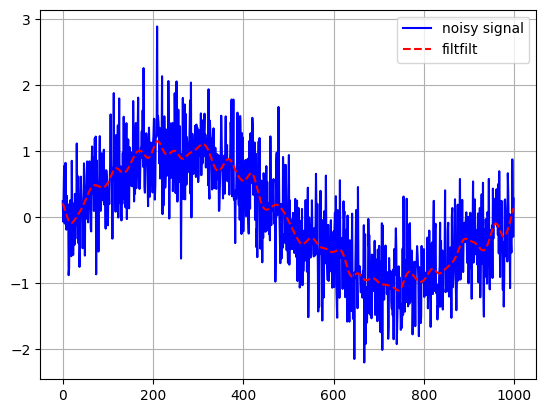

In [51]:
plt.figure()

plt.plot(x_train, 'b')

plt.plot(y, 'r--')

plt.legend(('noisy signal', 'filtfilt'), loc='best')

plt.grid(True)

plt.show()

In [13]:
# Prepare the training dataset.


# Prepare the training dataset.
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, s_train))
# train_dataset = train_dataset.shuffle(buffer_size=10).batch(batch_size)
train_dataset = train_dataset.batch(batch_size)


# Prepare the validation dataset.
# val_dataset = tf.data.Dataset.from_tensor_slices((x_val, s_val))
# val_dataset = val_dataset.batch(batch_size)


In [14]:
len(train_dataset)

16

In [15]:
for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
    print(x_batch_train.shape)

(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)


2025-10-17 08:43:52.827826: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [29]:
epochs = 20
for epoch in range(epochs):
    print("\nStart of epoch %d" % (epoch,))

    # Iterate over the batches of the dataset.
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
        # Open a GradientTape to record the operations run
        # during the forward pass, which enables auto-differentiation.
        with tf.GradientTape() as tape:
            # Run the forward pass of the layer.
            # The operations that the layer applies
            # to its inputs are going to be recorded
            # on the GradientTape.
            my_input_batched = tf.expand_dims(x_batch_train, axis=0)
            logits = model(my_input_batched, training=True)  # Logits for this minibatch

            # Compute the loss value for this minibatch.
            # TODO: loss function
            print(logits)
            seq_filt = apply_fir(x_batch_train, logits[0]) # TODO: check logits type
            loss = mse(y_batch_train, seq_filt)
            # loss_value = loss_fn(y_batch_train, logits)

        # Use the gradient tape to automatically retrieve
        # the gradients of the trainable variables with respect to the loss.
        grads = tape.gradient(loss, model.trainable_weights)

        # Run one step of gradient descent by updating
        # the value of the variables to minimize the loss.
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        # Log every 200 batches.
        if step % 200 == 0:
            print(
                "Training loss (for one batch) at step %d: %.4f"
                % (step, float(loss))
            )
            print("Seen so far: %s samples" % ((step + 1) * batch_size))



Start of epoch 0
tf.Tensor([[ 0.26958355 -0.03549429]], shape=(1, 2), dtype=float32)


ValueError: The length of `a` along the last axis must be at least 2.